# Create environment

In [1]:
from gymnasium.core import ObsType
from typing import Literal, Any, SupportsFloat
from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema
import numpy as np
from collections import defaultdict
import gymnasium as gym

class AfmEnvironment(gym.Env):
    metadata = {'render.modes': ['human', 'rgb_array']}
    
    def _compute_imgs(self, surface_path: str, params_path: str, i_platform: int = 0) -> tuple[AFMulator, np.ndarray]:
        """
        Generates AFM images with ppafm
        
        Parameters
        ----------
        surface_path : str
            Path to a .xyz file containing the surface
        params_path : str
            Path to a .ini file containing the parameters for the simulation
        i_platform : int
            Index of OpenCL device

        Returns
        -------
        AFMulator
            AFMulator object used to generate images
        np.ndarray
            Generated images. The second and third axis are already reversed.
        """
        init_env(i_platform=i_platform)
        xyzs, Zs, qs, _ = loadXYZ(surface_path)
        afmulator = AFMulator.from_params(params_path)
        afm_images = afmulator(xyzs, Zs, qs)
        
        return afmulator, afm_images[:,::-1,::-1]

    # TODO: Implement render mode
    # TODO: Figure out how to handle multiple surfaces at once
    def __init__(self,
            surface_path: str,
            params_path: str,
            i_platform: int = 0,
            sigma: int = 4,
            num_historic_data: int = 4,
            render_mode: Literal[None, 'human', 'rgb'] = None
        ) -> None:
        """
        Constructor
        
        Parameters
        ----------
        surface_path : str
            Path to a .xyz file containing the surface
        params_path : str
            Path to a .ini file containing the parameters for the simulation
        i_platform : int
            Index of OpenCL device
        render_mode : Literal[None, 'human', 'rgb']
            Render mode to use
        """
        super().__init__()

        self.num_historic_data = num_historic_data

        # Generate images
        self.afmulator, self.afm_images = self._compute_imgs(surface_path, params_path, i_platform)
        
        # Calculate heights for each slice
        self.z_height_map = np.linspace(
            self.afmulator.scan_window[0][2],
            self.afmulator.scan_window[1][2] - self.afmulator.df_steps * self.afmulator.dz,
            self.afmulator.scan_dim[2] - self.afmulator.df_steps + 1,
        )
        
        # Get all minima in the z direction and only keep the highest one
        minima = np.array(argrelextrema(self.afm_images, np.less_equal, axis=2)).T
        minima_dict = defaultdict(list)
        for xx, yy, zz in minima:
            minima_dict[xx, yy].append(zz)
            minima_dict[xx, yy] = [max(minima_dict[xx, yy])]
        
        argmin_image = np.zeros(self.afm_images.shape[0:-1], dtype=int)
        for pixel, val in minima_dict.items():
            argmin_image[pixel] = int(val[0])
        
        # Convert index to actual height and smooth optimal surface
        self.min_image = self.z_height_map[argmin_image]
        # TODO: Shift optimal height upwards?
        self.optimal_height = gaussian_filter(self.min_image, sigma=sigma)
        
        # Define observation space
        x_px_max, y_px_max, _ = self.afm_images.shape
        self.z_min = self.afmulator.scan_window[0][2]
        self.z_max = self.afmulator.scan_window[1][2] - self.afmulator.df_steps * self.afmulator.dz
        self.observation_space = gym.spaces.Dict(
            {
                "x": gym.spaces.Box(0, x_px_max - 1, shape=(num_historic_data,), dtype=np.int64),
                "y": gym.spaces.Box(0, y_px_max - 1, shape=(num_historic_data,), dtype=np.int64),
                "dz": gym.spaces.Box(-self.z_max, self.z_max, shape=(num_historic_data,), dtype=np.float64),
                "df": gym.spaces.Box(-np.inf, np.inf, shape=(num_historic_data,), dtype=np.float64),
            }
        )
        
        # Define action space
        # TODO: What is the maximum speed for the tip?
        self.action_space = gym.spaces.Box(-1, 1, shape=(1,), dtype=np.float64)

        self.reset()

    def _get_closest_slice_index(self, z: float) -> np.int64:
        """
        Returns the index of the slice closest to a given z height

        Parameters
        ----------
        z : float
            Height of the desired slice

        Returns
        -------
        int : index of the closest slice
        """
        return np.abs(self.z_height_map - z).argmin()

    def _get_two_closest_z_planes(self, z):
        """
        Returns the indices of the two closest values in array to the given value.

        Parameters
        ----------
        value : float
            The target value

        Returns
        -------
        tuple : (int, int)
            Indices of the two closest values in ascending order
        """
        return np.sort(np.argsort(np.abs(self.z_height_map - z))[0:2])


    def _get_interpolated_df(self, x: int, y: int, z: float):
        """
        Interpolates a value at the given xy coordinates
        for a specific height `z` using two closest z-planes.

        Parameters
        ----------
        x : int
            The x index
        y : int
            The y index
        z : float
            The z position at which the value needs to be interpolated.

        Returns
        -------
        float
            The interpolated value at the specified z-coordinate.
        """
        z1, z2 = self._get_two_closest_z_planes(z)
        k = (self.afm_images[x, y, z2] - self.afm_images[x, y, z1]) / (self.z_height_map[z2] - self.z_height_map[z1])
        return k * (z - self.z_height_map[z1]) + self.afm_images[x, y, z1]


    def _get_obs(self):
        """
        Convert internal state to observation format.

        Returns
        -------
        dict
            Observation dictionary with x and y position, difference to the starting height and change in frequency
        """
        return {
            "x": self._x,
            "y": self._y,
            "dz": self._dz,
            "df": self._df
        }

    def _get_info(self):
        """
        Compute auxiliary information for debugging.

        Returns
        -------
            dict : z height and corresponding index
        """
        return {
            "z:": self.z_start,
            "z_i": self.z_start_index,
            "generated_image": self.generated_image,
        }

    # TODO: Randomize start position and rotation. Maybe also switch between different surfaces?
    def reset(self, seed: int | None = None, options : dict[str, Any] | None = None) -> tuple[ObsType, dict[str, Any]]:
        """
        Resets the environment
        
        Parameters
        ----------
        seed : int | None
            Seed for the random number generator
        options : dict[str, Any] | None
            Options for super class

        Returns
        -------

        """
        super().reset(seed=seed, options=options)

        if seed is not None:
            np.random.seed(seed)

        self.terminated = False

        z = self.z_max - np.random.rand()
        self.z_start_index = self._get_closest_slice_index(z)
        self.z_start = self.z_height_map[self.z_start_index]

        self._x = np.zeros(self.num_historic_data, dtype=np.int64)
        self._y = np.zeros(self.num_historic_data, dtype=np.int64)
        self._dz = np.zeros(self.num_historic_data)
        self._df = self.afm_images[0, 0, self.z_start_index] * np.ones(self.num_historic_data)

        self.generated_image = np.empty(self.afm_images.shape[:2])
        self.generated_image[:] = np.nan
        self.generated_image[0, 0] = self._get_interpolated_df(0, 0, self.z_start)

        return self._get_obs(), self._get_info()

    def _insert_into_array(self, array : np.ndarray, data_point):
        """
        Modifies an array by rolling it to the right and inserting a new data point at the beginning.

        Parameters
        ----------
        array : numpy.ndarray
            The input array to be modified.
        data_point : Any
            The new data point

        Returns
        -------
        numpy.ndarray
            The modified array
        """
        array = np.roll(array, 1)
        array[0] = data_point
        return array
        
    def step(self, action) -> tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]:
        """Execute one timestep within the environment.

        Args:
            action: The distance in Ångström that the tip should move.

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        if self.terminated:
            return self._get_obs(), 0, True, False, self._get_info()

        x_px_max, y_px_max, _ = self.afm_images.shape
        x_current, y_current = int(self._x[0]), int(self._y[0])

        # Determine new position based on raster scan pattern
        if y_current % 2 == 0:  # Even rows: moving right
            if x_current + 1 >= x_px_max:
                # End of row reached, move to next row
                self._x = self._insert_into_array(self._x, x_current)
                self._y = self._insert_into_array(self._y, y_current + 1)
            else:
                # Move right
                self._x = self._insert_into_array(self._x, x_current + 1)
                self._y = self._insert_into_array(self._y, y_current)
        else:  # Odd rows: moving left
            if x_current - 1 < 0:
                # Beginning of row reached, move to next row
                self._x = self._insert_into_array(self._x, x_current)
                self._y = self._insert_into_array(self._y, y_current + 1)
            else:
                # Move left
                self._x = self._insert_into_array(self._x, x_current - 1)
                self._y = self._insert_into_array(self._y, y_current)

        x_new, y_new = int(self._x[0]), int(self._y[0])

        # Update dz and df
        # TODO: Clip z
        dz_new = self._dz[0] + action[0]
        self._dz = self._insert_into_array(self._dz, dz_new)
        z_new = self.z_start + dz_new
        self._df = self._insert_into_array(self._df, self._get_interpolated_df(x_new, y_new, z_new))
        self.generated_image[x_new, y_new] = self._df[0]

        # Check for crashes
        # TODO: Add tolerance?
        if z_new < self.min_image[x_new, y_new]:
            return self._get_obs(), -100, True, False, self._get_info()

        # TODO: Base reward should be set by variable
        reward = 10 - (z_new - self.optimal_height[x_new, y_new])

        if y_new % 2 == 0 and y_new == y_px_max - 1 and x_new == x_px_max - 1:
            self.terminated = True
        elif y_new % 2 == 1 and y_new == 0 and x_new == 0:
            self.terminated = True

        return self._get_obs(), reward, self.terminated, False, self._get_info()


 PACKAGE_PATH =  /home/henry/Documents/GDrive/DocumentsCloud/Uni/TU/InterdisciplinaryProject/repo/.venv/lib/python3.11/site-packages/ppafm
 CPP_PATH     =  /home/henry/Documents/GDrive/DocumentsCloud/Uni/TU/InterdisciplinaryProject/repo/.venv/lib/python3.11/site-packages/ppafm/cpp


## Initialize test environment

In [2]:
env = AfmEnvironment("materials/pt_111_small_rows_missing.xyz", "materials/params_code.ini")

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


In [3]:
env.reset(seed=123)
print(env._get_obs())
print(env.z_start_index)
print(env.z_start)
gym.spaces.Box(-np.inf, np.inf, shape=(1,), dtype=np.float64).sample()[0]

{'x': array([0, 0, 0, 0]), 'y': array([0, 0, 0, 0]), 'dz': array([0., 0., 0., 0.]), 'df': array([-0.0566851, -0.0566851, -0.0566851, -0.0566851])}
730
21.3


np.float64(1.2217060215931455)

## Automatic checker. Will fail, because of flawed internal logic.

In [6]:
from gymnasium.utils.env_checker import check_env

# Because there are nan values in the generated image, the env checker will fail.
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")

Environment has issues: Deterministic step info are not equivalent for the same seed and action


In [7]:
observation = env._get_obs()
print(observation["x"] in gym.spaces.Box(0, 200, shape=(4,), dtype=np.int64))
print(observation["y"] in gym.spaces.Box(0, 200, shape=(4,), dtype=np.int64))
print(observation["dz"] in gym.spaces.Box(-22., 22., shape=(4,), dtype=np.float64))
print(observation["df"] in gym.spaces.Box(-np.inf, np.inf, shape=(4,), dtype=np.float64))

True
True
True
True


## Manually test environment

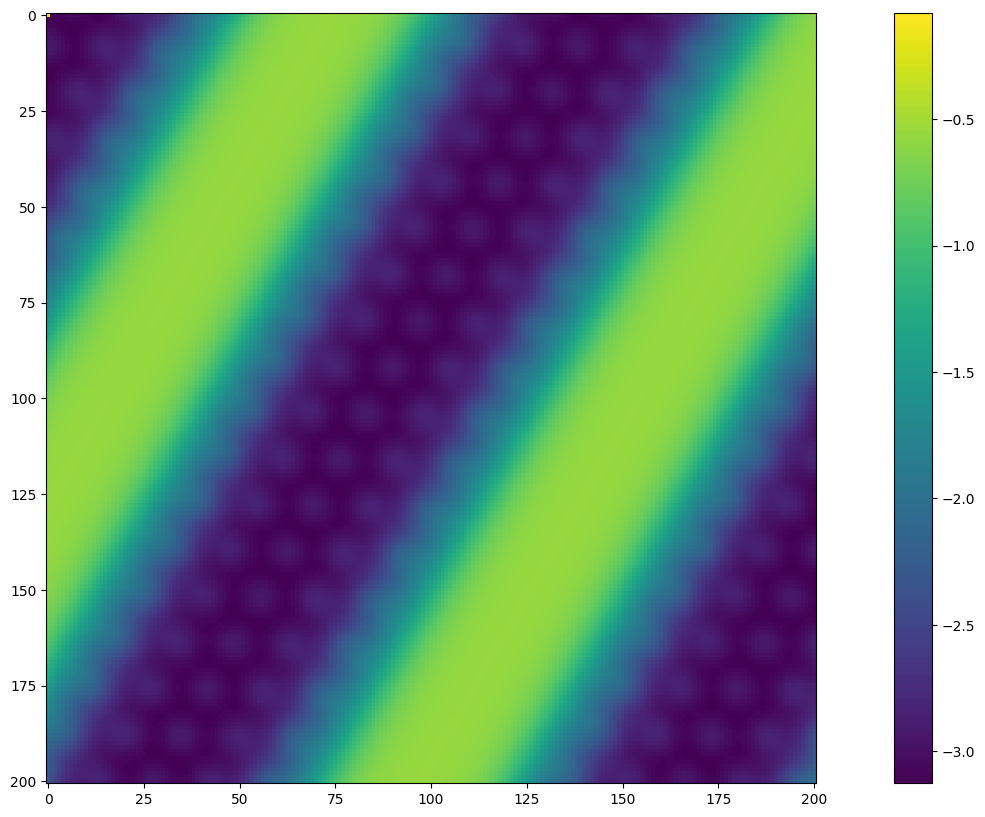

In [31]:
# Manually test environment. Reset, step to where we'll get a proper image and scan the same height
env.reset(123)
env.step([-5])

for i in range(201*201):
    env.step([0])

plt.imshow(env.generated_image.T)
plt.colorbar()

## Register environment

In [2]:
from gymnasium.envs.registration import register

register(
    id="gymnasium_env/AfmEnvironment-v0",
    # max_episode_steps=201*201,
    # reward_threshold=0.0,
    # kwargs={"surface_path": "materials/pt_111_small_rows_missing.xyz", "params_path": "materials/params_code.ini"},
    # nondeterministic=False,
    entry_point="gymnasium_env.envs:AfmEnvironment",
)


# Train simple agent

In [4]:
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
import os

# Create the environment directly using the class
# Define a factory function that creates a new environment instance
def make_env(rank=0):
    def _init():
        env = AfmEnvironment("materials/pt_111_small_5row_missing.xyz", "materials/params_code.ini")
        # Wrap with Monitor to track episode statistics
        env = Monitor(env, filename=os.path.join("./logs", f"env_{rank}"))
        return env
    return _init


# Create the vectorized environment with independent instances
env_arr = [make_env(i) for i in range(3)]
vec_env = DummyVecEnv(env_arr)

# env = make_env()

model = PPO(
    "MultiInputPolicy",
    vec_env,
    verbose=1,
    tensorboard_log="./tensorboard_logs"
)

checkpoint_callback = CheckpointCallback(
    save_freq=10000,  # Save every 10,000 timesteps
    save_path="./models/",
    name_prefix="ppo_afm_model",
    save_replay_buffer=False,
)

model.learn(
    total_timesteps=500000,
    progress_bar=True,
    tb_log_name="ppo_afm_env",
    callback=checkpoint_callback,
)
model.save("ppo_afm_env")


Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Using cuda device
Logging to ./tensorboard_logs/ppo_afm_env_5


Output()

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 252          |
|    ep_rew_mean          | -8.8         |
| time/                   |              |
|    fps                  | 1440         |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 12288        |
| train/                  |              |
|    approx_kl            | 0.0052575767 |
|    clip_fraction        | 0.0584       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.000495     |
|    learning_rate        | 0.0003       |
|    loss                 | 3.4e+03      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00546     |
|    std                  | 0.999        |
|    value_loss           | 1.19e+04     |
------------------------------------------
------------------------------------------
| rollout/ 

In [2]:
from stable_baselines3 import PPO

env = AfmEnvironment("materials/pt_111_small_5row_missing.xyz", "materials/params_code.ini")
model = PPO.load("ppo_afm_env")

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


In [21]:
obs_arr, rewards_arr, info_arr, action_arr = [], [], [], []
obs, info = env.reset()
obs_arr.append(obs)
info_arr.append(info)

for i in range(201*201):
    action, _states = model.predict(obs)
    action_arr.append(action)
    obs, rewards, terminated, truncated, info = env.step(action)

    obs_arr.append(obs)
    rewards_arr.append(rewards)
    info_arr.append(info)

    if i%100 == 0:
        print(i)
    if terminated:
        break

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [22]:
generated_image = info["generated_image"]

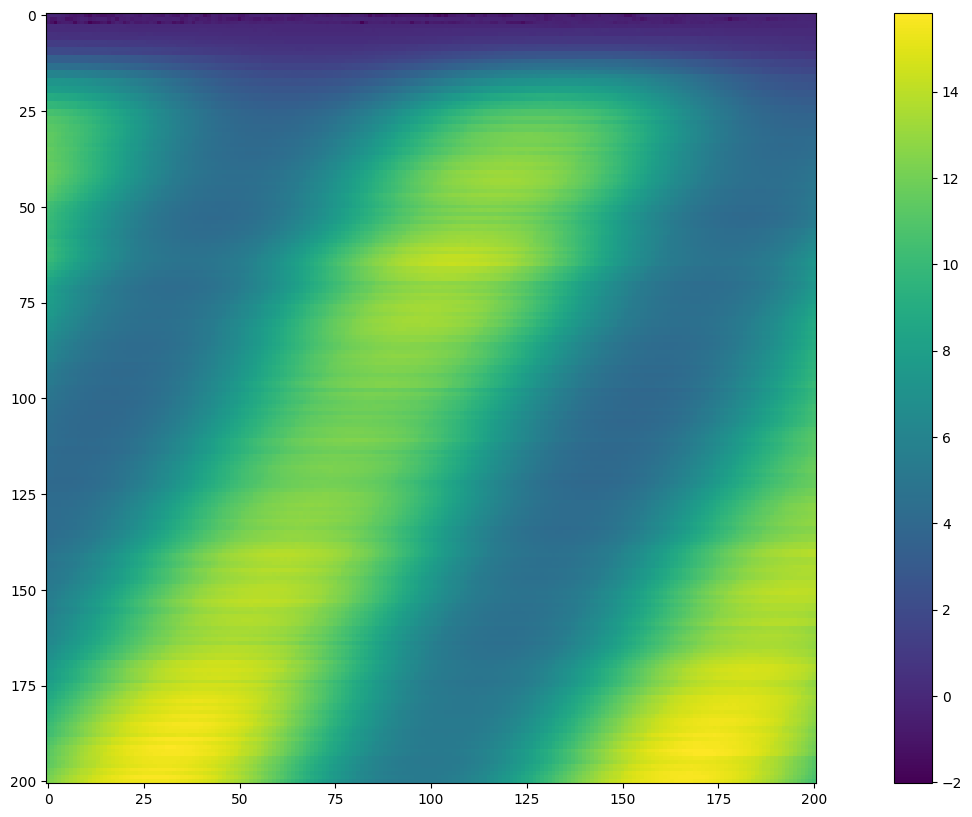

In [32]:
plt.imshow(info["generated_image"].T)
plt.colorbar()

In [38]:
np.array(action_arr).flatten()

array([-0.50501949, -0.052311  , -0.36765718, ..., -0.42299816,
       -0.36815464,  0.52557683], shape=(40400,))

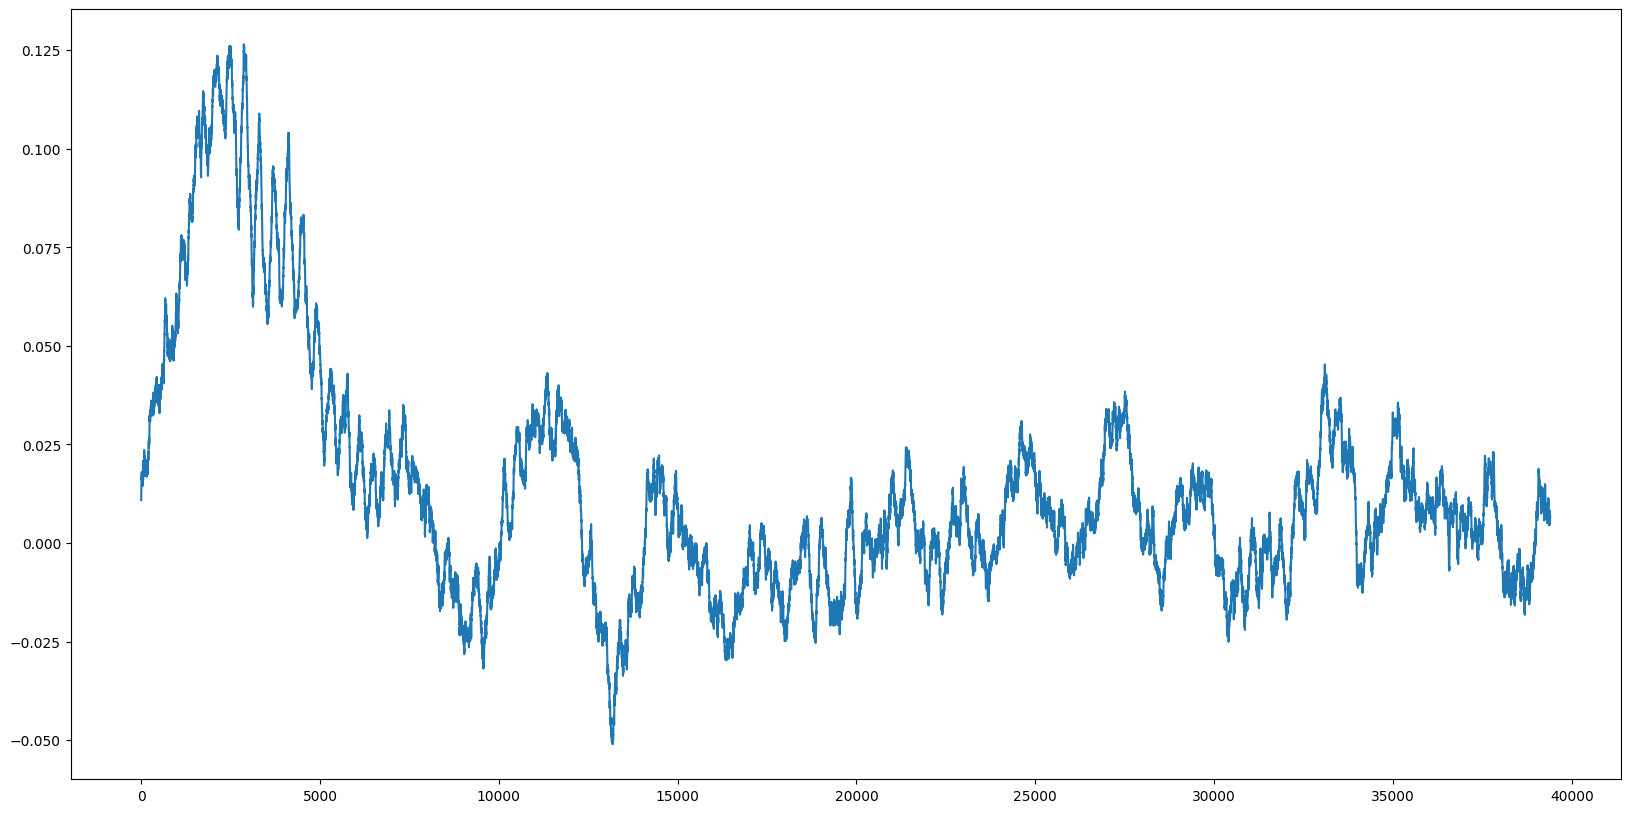

In [42]:
plt.rcParams["figure.figsize"] = (20, 10)

window_size = 1000

moving_avg = np.convolve(np.array(action_arr).flatten(), np.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)